In [1]:
import numpy as np
import xarray as xr
from matplotlib import pyplot as plt
import pandas as pd
from fonts_config import set_computer_modern, truncate_colormap
set_computer_modern()
import matplotlib as mpl
mpl.rcParams['axes.unicode_minus'] = False
import matplotlib.lines as mlines
from matplotlib.patches import Rectangle, Patch, Polygon
import glob
import os
import string
import re
from matplotlib.legend_handler import HandlerTuple
from scipy.stats import gaussian_kde
import seaborn as sns

from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.patches import Rectangle
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import matplotlib.container as container

from matplotlib.colors import LinearSegmentedColormap



In [2]:
LGM = xr.open_dataset("../output/LGM_ens.nc")
LGM_sel = xr.open_dataset("../output/LGM_sel.nc")

hol = xr.open_dataset("../output/HTM_ens.nc")
hol_sel = xr.open_dataset("../output/HTM_sel.nc")

n_best = 2572
top_sel = 5
scores = xr.open_dataset("../scoring/scores/scores2.nc")

In [3]:
# ----------------------------------------------------------------------------
# Paths
# ----------------------------------------------------------------------------

labels  = ["Clark & Mix (2002)", "Huybrechts (2002)", "Flemming & Lambeck (2004)", "local LGM Simpson et al. (2009)", "LGM Simpson et al. (2009)","local Lecavalier et al. (2014)",
           "Lecavalier et al. (2014)","Bradley et al. (2018)","Buizert et al. (2018)", "Tabone et al. (2018)", "Quiquet et al. (2021)","local LGM Leger et al. (2025)"]
V_sle = [2.5, 2.7, 3.1, 4.6, 4.1, 5.1, 4.7, 2.59, (3.1+4.5)/2, (5.3+4.6)/2, 2.6, (7.5+6)/2]
err   = [0.5, 0.8, 0,   0,   0,   0,   0,   0, (-3.1+4.5)/2,(5.3-4.6)/2, 0, (7.5-6)/2]

ds_lgm = xr.Dataset(
    data_vars={
        "V_sle": (["sim"], V_sle, {"units": "m", "long_name": "Sea Level Equivalent"}),
        "error": (["sim"], err, {"units": "m", "long_name": "Uncertainty"})
    },
    coords={
        "sim": list(range(len(V_sle))),   
        "label": (["sim"], labels)})


In [4]:
# ----------------------------------------------------------------------------
# Paths
# ----------------------------------------------------------------------------

labels  = ["Simpson et al. (2009)", "Lecavalier et al. (2014)","Buizert et al. (2018)", "Nielsen et al. (2018)", "Yang et al. (2022)"]
HTM_sle = [-0.17, -0.16, -0.55/2, -(0.15+1.2)/2, -0.2]
err   = [0,   0,     0.55/2,    (-0.15+1.2)/2, 0]

ds_hol = xr.Dataset(
    data_vars={
        "V_sle": (["sim"], HTM_sle, {"units": "m", "long_name": "Sea Level Equivalent"}),
        "error": (["sim"], err, {"units": "m", "long_name": "Uncertainty"})
    },
    coords={
        "sim": list(range(len(HTM_sle))),   
        "label": (["sim"], labels)})


<>:121: SyntaxWarning: invalid escape sequence '\D'
<>:121: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_502716/1474089365.py:121: SyntaxWarning: invalid escape sequence '\D'
  ax.set(ylabel=f'{era} $\Delta$GMSL (m)')


Resultados Acumulación LGM:
  Best sim: -5.75
  Rango 68% (Prob. Accum): [-6.31, -3.93]
  Rango 95% (Prob. Accum): [-6.31, -3.57]
Resultados Acumulación HTM:
  Best sim: 0.45
  Rango 68% (Prob. Accum): [0.45, 1.18]
  Rango 95% (Prob. Accum): [0.43, 1.23]


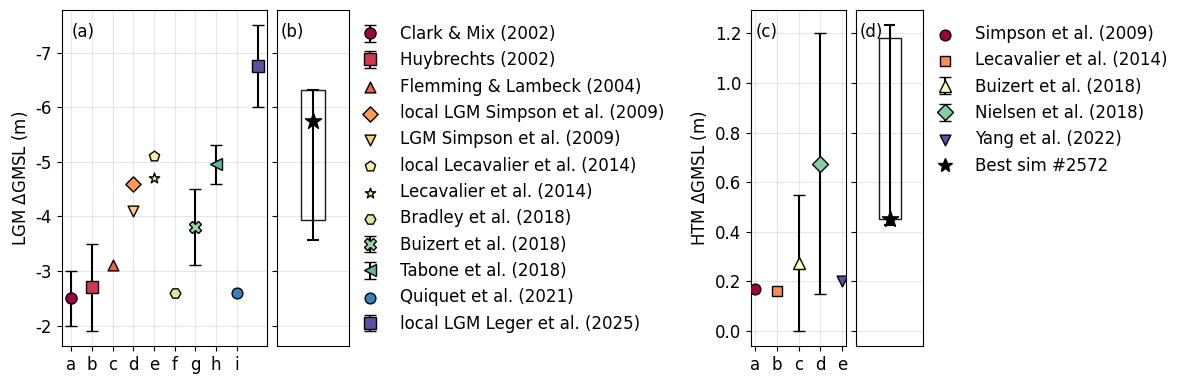

In [5]:

def plot_uncertainty_accumulation_box2(ax, df_vals, weights, y_best):
    """
    Nueva versión: Representa el rango físico de las simulaciones 
    que acumulan el 68% y 95% de la probabilidad total.
    """
    # 1. Crear DataFrame temporal para ordenar
    temp_df = pd.DataFrame({'val': df_vals, 'w': weights})
    # Ordenar por peso de mayor a menor
    temp_df = temp_df.sort_values(by='w', ascending=False).reset_index(drop=True)
    # Calcular suma acumulada de pesos
    temp_df['cum_w'] = temp_df['w'].cumsum() / temp_df['w'].sum()

    # 2. Encontrar rangos físicos (Min y Max de las simulaciones que entran en el corte)
    # Corte 68%
    top_68 = temp_df[temp_df['cum_w'] <= 0.68]
    # Si por casualidad la primera ya es > 0.68, tomamos al menos la mejor
    if top_68.empty: top_68 = temp_df.head(1)
    r68_min, r68_max = top_68['val'].min(), top_68['val'].max()

    # Corte 95%
    top_95 = temp_df[temp_df['cum_w'] <= 0.95]
    r95_min, r95_max = top_95['val'].min(), top_95['val'].max()

    # 3. Dibujar "Bigotes" (Rango 95%)
    ax.vlines(0, r95_min, r95_max, color='black', linestyle='-', lw=1.5)
    ax.hlines([r95_min, r95_max], xmin=-0.1, xmax=0.1, color='black', lw=1.5)

    # 4. Dibujar "Caja" (Rango 68%)
    box_width = 0.4
    # La caja va desde el mínimo del top 68% al máximo del top 68%
    rect = Rectangle((-box_width/2, r68_min), box_width, r68_max - r68_min, 
                     facecolor="none", edgecolor='black', zorder=3, alpha=0.9)
    ax.add_patch(rect)

    # 5. Dibujar la Mejor Simulación (Línea horizontal dentro de la caja y Estrella)
    ax.scatter(0, y_best, color='black', edgecolor='black', marker='*', s=150, zorder=5, label='Best Sim')

    # Ajustes estéticos
    ax.set_xlim(-0.6, 0.6)
    ax.set_xticks([])
    
    return r68_min, r68_max, r95_min, r95_max

    
    
def plot_compare_lgm3(ax, ds, df, vols, n_best, top_sel, era,label):
    mks = ['o', 's', '^', 'D', 'v', 'p', '*', 'H', 'X', '<']
    letters = list(string.ascii_lowercase)
    cmap = plt.get_cmap('Spectral')
    n = len(ds.sim)
    h_list, l_list = [], []
    j = 0
    
    # Plot de los puntos individuales
    for i, s_id in enumerate(ds.sim.values):
        d = ds.sel(sim=s_id)
        c = cmap(i / (n - 1)) if n > 1 else cmap(0.5) 
        m = mks[i % len(mks)]
        label_str = str(d.label.values.item())
        
        if d.error == 0:
            h = ax.scatter(j, -d.V_sle, marker=m, color=c, s=60, edgecolors='black', zorder=5)
        else:
            h = ax.errorbar(j, -d.V_sle, yerr=d.error, fmt=m, color=c, markersize=8, 
                           markeredgecolor='black', ecolor='black', capsize=4, zorder=5)
        
        h_list.append(h)
        l_list.append(label_str)
        
        if "local" not in label_str.lower():
            j += 1

    # --- CREAR EJE PARA EL VIOLÍN ---
    divider = make_axes_locatable(ax)
    if era == "LGM":
        size_violin="35%"
        pad_leg = 1.35
    else:
        size_violin="70%"
        pad_leg = 1.7
    ax_violin = divider.append_axes("right", size=size_violin, pad=0.1, sharey=ax)
    
    df_resampled = df.sample(n=3000, replace=True, weights='weight')
    # sns.violinplot(y=df_resampled['data'], ax=ax_violin, color='skyblue', edgecolor="black",inner=None)

    kernel = gaussian_kde(df.data, weights=sco)
    # Creamos un rango de puntos para evaluar el KDE
    x_range = np.linspace(df.data.min(), df.data.max(), 1000)
    y_best = -vols.dV_sle.sel(sim=n_best).values

    # --- Print resultados ---
    r68_low, r68_high, r95_low, r95_high = plot_uncertainty_accumulation_box2(
        ax_violin, df.data.values, df.weight.values, y_best
    )

    print(f"Resultados Acumulación {era}:")
    print(f"  Best sim: {y_best:.2f}")
    print(f"  Rango 68% (Prob. Accum): [{r68_low:.2f}, {r68_high:.2f}]")
    print(f"  Rango 95% (Prob. Accum): [{r95_low:.2f}, {r95_high:.2f}]")
    
    # Limpieza estética del eje del violín
    ax_violin.set_xlabel("")
    ax_violin.set_ylabel("")
    ax_violin.grid(axis='both', alpha=0.3)
    plt.setp(ax_violin.get_yticklabels(), visible=False) # Ocultar números del eje Y repetidos

    if era == "LGM":
        ax.invert_yaxis() # Esto invertirá ambos porque comparten yaxis

    # Leyenda (usando un proxy para el violín)
    if era == "HTM":
        proxy_violin = mpatches.Patch(facecolor='skyblue', edgecolor='black',label='Densidad (WECDF)')
        proxy_best = Line2D([0], [0], marker='*', color='w', markerfacecolor='black', 
                    markeredgecolor='black', markersize=10)
        h_list.extend([proxy_best])
        l_list.extend([f'Best sim #{n_best}'])
    
    ax.legend(h_list, l_list, bbox_to_anchor=(pad_leg, 1), loc='upper left', frameon=False)
    ax.set_xticks(range(j))
    ax.set_xticklabels(letters[:j])
    ax.set(ylabel=f'{era} $\Delta$GMSL (m)')
    ax.grid(axis='both', alpha=0.3)

    ax.text(0.05, 0.92, label[0], transform=ax.transAxes)
    ax_violin.text(0.05, 0.92, label[1], transform=ax_violin.transAxes,zorder=1)

    return

# Cálculos del KDE pesado
data = -LGM.dV_sle.values.flatten()
sco = scores.S.values / scores.S.values.sum()
df1 = pd.DataFrame({'data': data, 'weight': scores.S.values})

kde = gaussian_kde(data, weights=sco)
y_range1 = np.linspace(min(data), max(data), 100)
v_density1 = kde(y_range1)

data = -hol.dV_sle.values.flatten()
sco = scores.S.values / scores.S.values.sum()
kde = gaussian_kde(data, weights=sco)
y_range2 = np.linspace(min(data), max(data), 100)
v_density2 = kde(y_range2)
df2 = pd.DataFrame({'data': data, 'weight': scores.S.values})

fig, ax = plt.subplots(1, 2, figsize=(12, 4), gridspec_kw={'width_ratios': [5, 3]})

plot_compare_lgm3(ax[0], ds_lgm, df1, LGM, n_best, top_sel, "LGM",label=["(a)","(b)"])
plot_compare_lgm3(ax[1], ds_hol, df2, hol, n_best, top_sel, "HTM",label=["(c)","(d)"])


plt.tight_layout()
plt.savefig(f"../figs_final/fig15_{n_best}_compare_lgm_hol", dpi=300)